In [51]:
import os
import sys

ROOT = os.path.abspath("..")  
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [52]:
from convo import (
    make_kernel,
    slow_convolve
)
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image


In [53]:
k = make_kernel(5, 20)

im = np.array(Image.open('../data/input1.jpg'))

if im.ndim == 3:
    blurred = np.stack([slow_convolve(im[:, :, c], k) for c in range(im.shape[2])], axis=2)
else:
    blurred = slow_convolve(im, k)

unsharp_mask = im - blurred
sharpened = im + unsharp_mask
sharpened = np.clip(sharpened, 0, 255).astype(np.uint8)

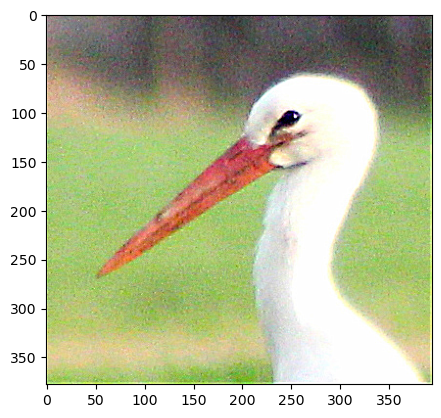

In [54]:
plt.imshow(sharpened)
plt.show()